In [139]:
import pandas as pd
import keras
import tensorflow
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from itertools import combinations

In [140]:
df = pd.read_excel('amostras_inferenciadas.xlsx', engine='openpyxl', sheet_name='18_02_2020')

In [141]:
df.head(5)

,ID,AT,AC,OFERTA,VC,intervalo,UNI,"UNIx0,8 + ITBI","UNIx0,9 + ITBI",VP,...,ZH,PAV,UNI-PRA,CC,TIPO,END,BAIRRO,FONTE / IF,longitude,latitude
0,1,700.0,560,2100000.0,1.481028e+06,501-700,884.0,707.2,795.6,1,...,4,1,145.3827,1,GALPÃO,"AV VEREADOR DA COSTA RIOS, 1111",CENTRO,CIOFFI IMOVEIS,-45.930455,-22.245445
1,2,380.0,253,1100000.0,6.301932e+05,1001-1500,1236.0,988.8,1112.4,0,...,6,1,48.4600,0,RESIDENCIAL,"RUA PEDRO CALDAS REBELLO, 290",SANTO IVO,CIOFFI IMOVEIS,-45.923179,-22.219603
2,4,450.0,350,1900000.0,1.268652e+06,1001-1500,1403.0,1122.4,1262.7,0,...,6,1,672.0000,0,RESIDENCIAL,"RUA PROF MARIA FERNANDES CASCALLI, 105",FATIMA I,CIOFFI IMOVEIS,-45.915588,-22.221595
3,5,270.0,140,650000.0,3.677250e+05,701-1000,1045.0,836.0,940.5,0,...,5,1,116.2800,0,RESIDENCIAL,"RUA MARIO DE FREITAS CARDOSO, 20",POUSADA DOS CAMPOS III,CIOFFI IMOVEIS,-45.916247,-22.210899
4,6,300.0,0,200000.0,0.000000e+00,701-1000,667.0,533.6,600.3,0,...,5,1,62.0100,0,TERRENO,"RUA BENONE FERREIRA DA COSTA, AO LADO DO 205",NOSSA SENHORA DO PILAR II,CIOFFI IMOVEIS,-45.935582,-22.213639


In [142]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target')
df['tipo'] = df['tipo'].str.replace(' ', '').str.lower()

In [143]:
df = pd.get_dummies(df, columns=['tipo'], dtype=int)
df.columns

Index(['id', 'at', 'ac', 'oferta', 'vc', 'intervalo', 'uni', 'unix0,8_+_itbi',
       'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7',
       'z8', 'z9', 'itbi/of', 'zh', 'pav', 'uni-pra', 'cc', 'end', 'bairro',
       'fonte_/_if', 'longitude', 'latitude', 'tipo_apartamento', 'tipo_casa',
       'tipo_comercial', 'tipo_galpão', 'tipo_predio', 'tipo_residencial',
       'tipo_terreno'],
      dtype='object')

In [144]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target').str.replace('ã', 'a')
df = df[['at', 'ac', 'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4',
         'z5', 'z6', 'z7', 'z8', 'z9', 'pav', 'cc', 'longitude', 'latitude',
       'tipo_casa', 'tipo_comercial',  'tipo_galpao', 'tipo_predio',
        'tipo_residencial', 'tipo_terreno']]

In [ ]:
kml_path = "zoneamento.kml"

gdf_kml = gpd.read_file(kml_path, driver='KML')

print(gdf_kml.head())


  Name Description                                           geometry
0                   MULTILINESTRING Z ((-45.9722 -22.24319 0, -45....


/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'zoneamento.kml': 'dissolved' (default), 'puparetificadissolvido', 'zepam1of', 'zep', 'zeep', 'zoneamentodissolvido'. Specify layer parameter to avoid this warning.
  result = read_func(


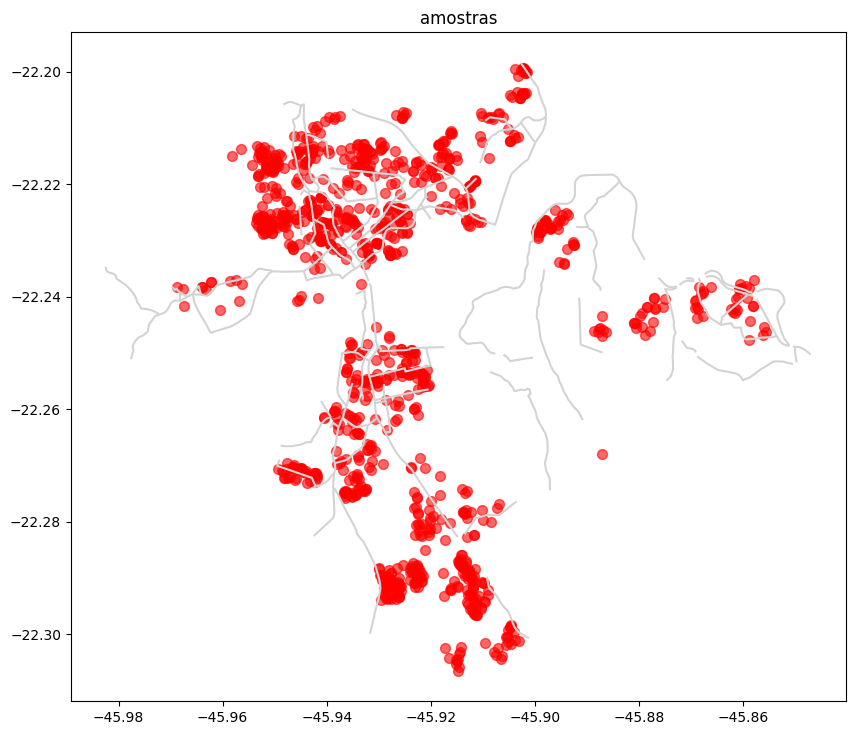

In [ ]:
geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry)
gdf_points.set_crs(epsg=4326, inplace=True)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_kml.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf_points.plot(ax=ax, color='red', markersize=50, alpha=0.6)

plt.title("amostras")
plt.show()

In [147]:
#find value that contains '-'
df[df.isin(['-']).any(axis=1)]

,at,ac,target,vp,vs,ov,z1,z2,z3,z4,...,pav,cc,longitude,latitude,tipo_casa,tipo_comercial,tipo_galpao,tipo_predio,tipo_residencial,tipo_terreno
31,1008.0,200,198.000000,0,0,1,0,0,0,0,...,-,0,-45.887106,-22.268053,0,0,0,0,1,0
107,627.0,0,186.300000,0,1,0,0,1,0,0,...,-,0,-45.909649,-22.301647,0,0,0,0,0,1
131,600.0,0,202.500000,0,0,1,0,1,0,0,...,-,0,-45.914862,-22.306548,0,0,0,0,0,1
132,600.0,0,180.000000,0,0,1,0,1,0,0,...,-,0,-45.915258,-22.304676,0,0,0,0,0,1
479,240.0,-,300.000000,0,0,1,0,0,1,0,...,1,0,-45.887847,-22.246333,0,0,0,0,0,1
482,1500.0,-,147.000000,0,0,1,0,1,0,0,...,1,0,-45.877180,-22.240264,0,0,0,0,0,1
483,800.0,-,281.250000,0,0,1,0,1,0,0,...,1,0,-45.877030,-22.242147,0,0,0,0,0,1
487,700.0,-,141.428571,0,0,1,0,1,0,0,...,1,0,-45.879864,-22.243530,0,0,0,0,0,1
488,800.0,-,337.500000,0,0,1,0,1,0,0,...,1,0,-45.879357,-22.243005,0,0,0,0,0,1
492,200.0,-,292.500000,0,0,1,0,1,0,0,...,1,0,-45.913394,-22.289600,0,0,0,0,0,1


In [148]:
#replace values that have "-" with null
df.replace("-", pd.NA, inplace=True)
df.dropna(inplace=True)

In [149]:
df.columns

Index(['at', 'ac', 'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4', 'z5',
       'z6', 'z7', 'z8', 'z9', 'pav', 'cc', 'longitude', 'latitude',
       'tipo_casa', 'tipo_comercial', 'tipo_galpao', 'tipo_predio',
       'tipo_residencial', 'tipo_terreno'],
      dtype='object')

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

all_features = list(X.columns)
min_features_to_retain = 5

while len(all_features) > min_features_to_retain:
    base_score = np.mean(cross_val_score(model, X[all_features], y, cv=5, scoring='r2'))

    worst_score = base_score
    worst_feature = None

    for feature in all_features:
        candidate_features = [f for f in all_features if f != feature]

        scores = cross_val_score(model, X[candidate_features], y, cv=5, scoring='r2')
        mean_score = np.mean(scores)

        
        if mean_score >= worst_score:
            worst_score = mean_score
            worst_feature = feature

    if worst_feature is not None:
        all_features.remove(worst_feature)
        print(f"Removed Feature: {worst_feature}, New CV R²: {worst_score:.4f}")
    else:
        print("Nenhuma feature pode ser removida sem piorar o modelo. Parando.")
        break

print("Remaining features:", all_features)

Removed Feature: longitude, New CV R²: -0.0656
Removed Feature: at, New CV R²: -0.0250
Removed Feature: tipo_predio, New CV R²: -0.0132
Nenhuma feature pode ser removida sem piorar o modelo. Parando.
Remaining features: ['ac', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'pav', 'cc', 'latitude', 'tipo_casa', 'tipo_comercial', 'tipo_galpao', 'tipo_residencial', 'tipo_terreno']


In [156]:
(df["ac"] == 0).value_counts()

ac
True     655
False    410
Name: count, dtype: int64

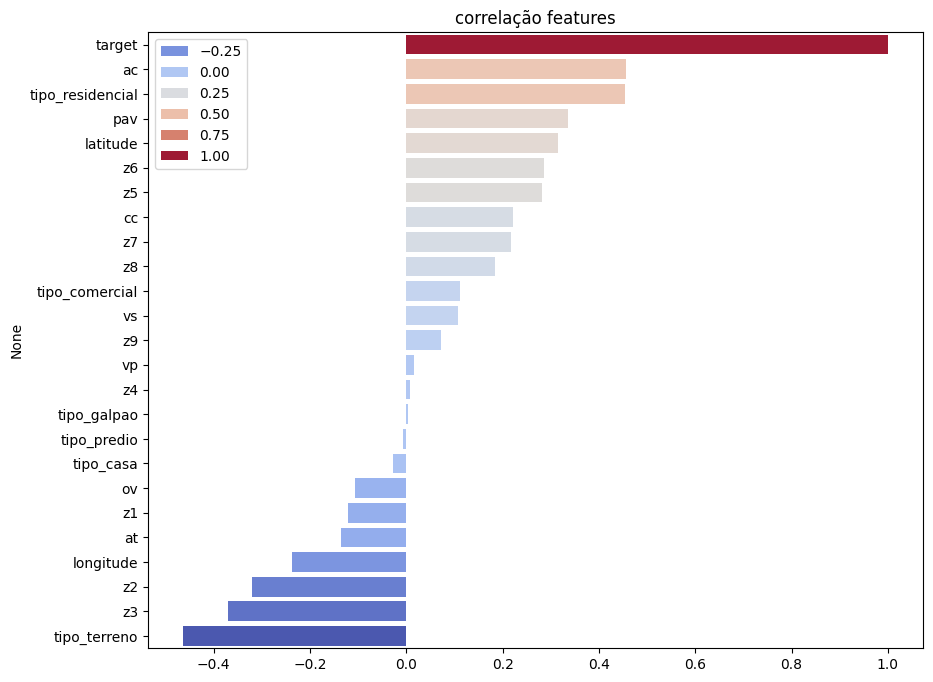

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_target = df.corr(method='spearman')['target'].sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.values, palette='coolwarm')
plt.title("correlação features")
plt.show()